# Day 3: Baseline Models (Logistic Regression & Decision Trees)

Before searching for the highly non-linear $H \to \tau\tau$ signal, we must establish a mathematical baseline. 
First, we quickly rerun our Day 2 preprocessing pipeline to load the data, handle the missing `-999.0` detector anomalies, and scale our phase space so every kinematic feature has $\mu=0$ and $\sigma=1$.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Running Preprocessing Pipeline...")
df = pd.read_csv('training.csv').replace(-999.0, np.nan)

cols_to_drop = df.columns[df.isna().mean() > 0.70].tolist() + ['EventId', 'Weight']
df_clean = df.drop(columns=cols_to_drop)

for col in df_clean.columns:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean['Label'] = df_clean['Label'].map({'s': 1, 'b': 0})
X = df_clean.drop(columns=['Label'])
y = df_clean['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Pipeline complete. Training phase space: {X_train.shape}")

Running Preprocessing Pipeline...
Pipeline complete. Training phase space: (200000, 23)


## 1. The Convex Baseline: Logistic Regression
We attempt to slice the 24-dimensional phase space with a single flat hyperplane: $\vec{w}^T\vec{x} + b = 0$. 
Because the invariant mass of the Higgs is a strictly non-linear combination of the raw momentum vectors, we expect this linear model to struggle. However, it provides our absolute performance floor by minimizing the binary cross-entropy loss.

In [2]:
print("--- Training Logistic Regression ---")
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_log):.4f}\n")
print(classification_report(y_test, y_pred_log))

--- Training Logistic Regression ---
Accuracy: 73.85%
ROC-AUC Score: 0.7985

              precision    recall  f1-score   support

           0       0.77      0.85      0.81     32867
           1       0.65      0.52      0.58     17133

    accuracy                           0.74     50000
   macro avg       0.71      0.69      0.69     50000
weighted avg       0.73      0.74      0.73     50000



## 2. The Non-Linear Baseline: Decision Trees
Instead of a flat plane, the Decision Tree applies sequential, orthogonal kinematic cuts (e.g., $p_T > 30 \text{ GeV}$). By minimizing the Gini Impurity at each node, it recursively carves the phase space into non-linear hyper-rectangles, naturally capturing the invariant mass resonance without us having to manually program the $M = \sqrt{E^2 - p^2}$ equation.

In [3]:
print("--- Training Decision Tree ---")
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42)

tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
y_prob_tree = tree_clf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_tree) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_tree):.4f}\n")
print(classification_report(y_test, y_pred_tree))

--- Training Decision Tree ---
Accuracy: 81.90%
ROC-AUC Score: 0.8804

              precision    recall  f1-score   support

           0       0.86      0.87      0.86     32867
           1       0.75      0.72      0.73     17133

    accuracy                           0.82     50000
   macro avg       0.80      0.79      0.80     50000
weighted avg       0.82      0.82      0.82     50000



Extracting Gini Importances from the Decision Tree...


C:\Users\harsh\AppData\Local\Temp\ipykernel_22456\2523982268.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


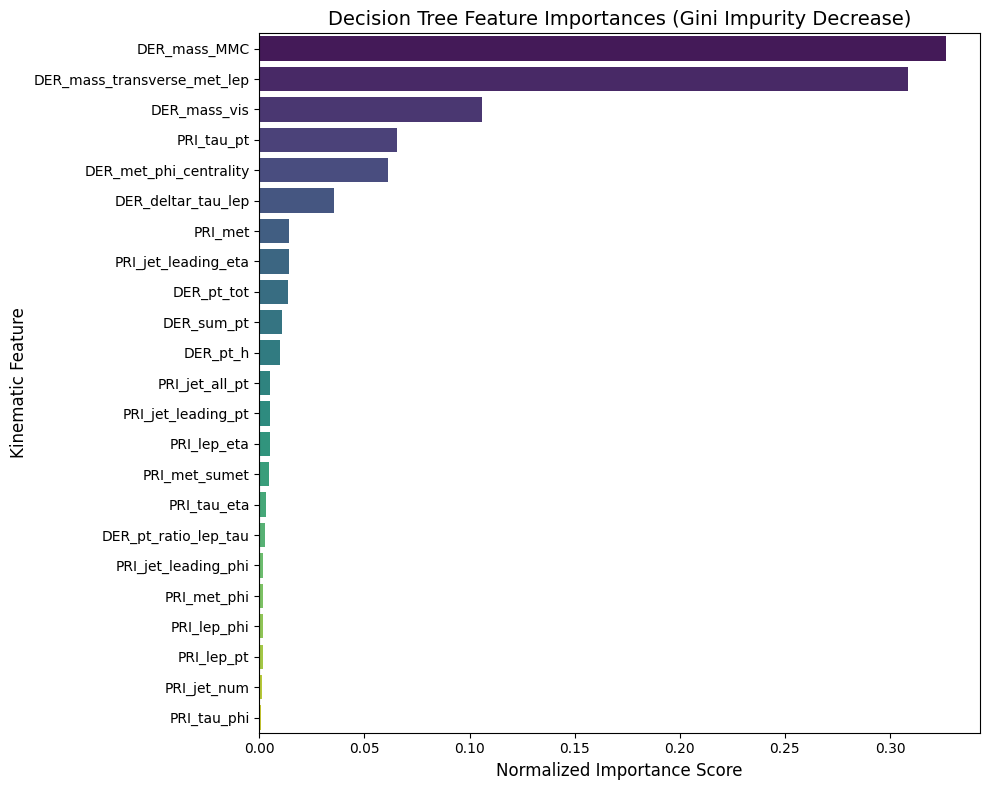


Top 3 Dominant Physics Features:
                    Feature  Importance
               DER_mass_MMC    0.326500
DER_mass_transverse_met_lep    0.308691
               DER_mass_vis    0.105699


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting Gini Importances from the Decision Tree...")

importances = tree_clf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree Feature Importances (Gini Impurity Decrease)', fontsize=14)
plt.xlabel('Normalized Importance Score', fontsize=12)
plt.ylabel('Kinematic Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 3 Dominant Physics Features:")
print(importance_df.head(3).to_string(index=False))